In [2]:
import numpy as np
import matplotlib.pyplot as plt

import Voronoi as Voronoi
import MonteCarlo as MonteCarlo
import Graphene as Graphene
import LammpsWriter as LammpsWriter
import Run_anneal as Run_anneal
%load_ext autoreload
%autoreload 2

Monte Carlo Sweeps: 100%|██████████| 20000/20000 [00:00<00:00, 31661.50it/s]


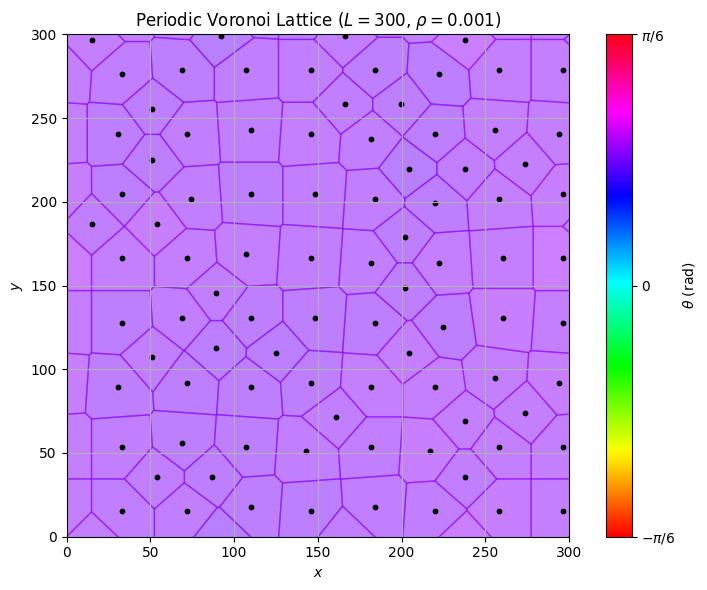

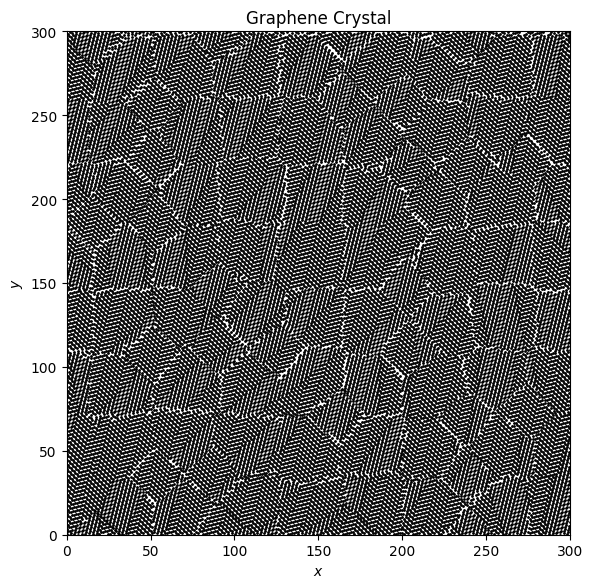

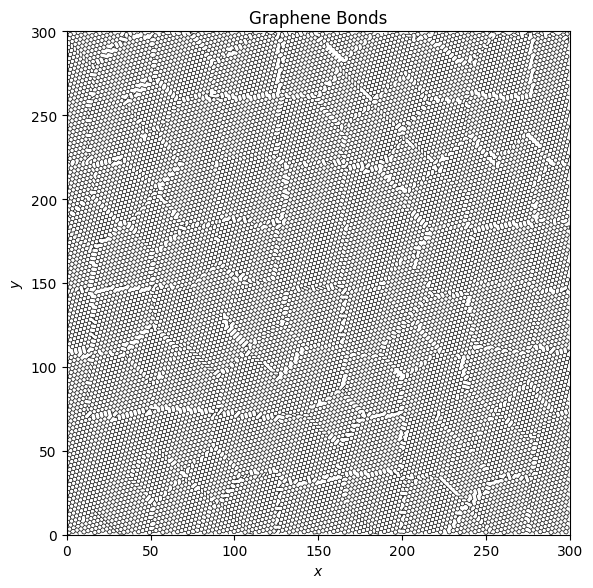

In [15]:
T = 1
L = 300
rho = 0.001
gamma = 1
epsilon = 0

vor = Voronoi.PeriodicVoronoi(L, rho)

thetas, _ = MonteCarlo.monte_carlo(vor.theta, vor.adj_i, vor.adj_j, vor.adj_length, 1/T, epsilon, rho, gamma, 20000)
vor.theta = thetas
vor.plot()
plt.show()

graphene = Graphene.GrapheneCrystal(vor, a=1.42)
graphene.plot_atoms()
plt.show()
graphene.plot_bonds()
plt.show()


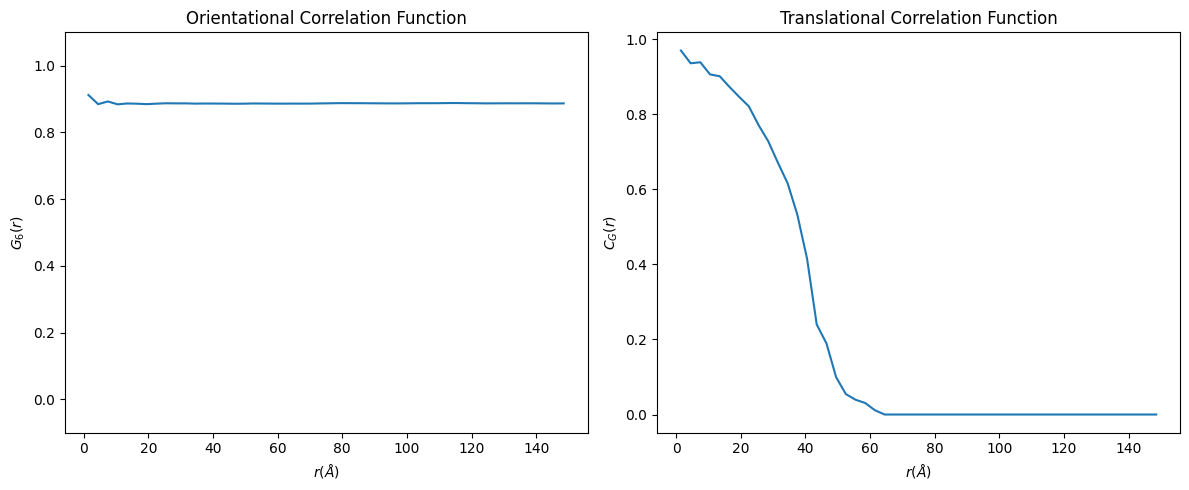

In [16]:
bin_bounds, G6, CG = graphene.compute_observables()

bin_centers = (bin_bounds[:-1] + bin_bounds[1:]) / 2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(bin_centers, G6)
ax1.set_xlabel(r'$r (\AA)$')
ax1.set_ylabel(r'$G_6(r)$')
ax1.set_title('Orientational Correlation Function')
ax1.set_ylim(-0.1, 1.1)

ax2.plot(bin_centers, CG)
ax2.set_xlabel(r'$r (\AA)$')
ax2.set_ylabel(r'$C_G(r)$')
ax2.set_title('Translational Correlation Function')

plt.tight_layout()
plt.show()